<a href="https://colab.research.google.com/github/himanshira/Machine-Learning/blob/main/Predicting_Sales_from_Campaign_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement
The objective of this case study is to build a predictive model that can estimate product sales generated from influencer marketing campaigns. You will work with real-world, messy campaign data and try to understand which campaign attributes actually drive sales.


### Load libraries and dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train = pd.read_csv('/content/messy_train_data.csv')
test = pd.read_csv('/content/messy_test_data.csv')

train.head()

,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,Sales (Units),ID,Timestamp,Notes
0,106572.0,2.573174871146172,2614.3781948587675,5.275680,6340,9254,2021-11-27,Pending
1,77583.0,0.9394984315675532,4975.962514379572,8.756268,5793,1561,2022-02-13,Review
2,92832.0,2.1761012652155296,4107.769534318886,6.454727,8104,1670,2023-09-25,Pending
3,53565.0,1.4783757541486553,4293.330464613049,4.312813,7293,6087,2023-02-15,Review
4,121079.0,3.3741976179329356,5343.549440897207,3.769047,14396,6669,2023-05-28,NaN


In [ ]:
copy_of_train = train.copy()

# Section A: Data Understanding & Cleaning

### Goal
Prepare the raw campaign data so it can be reliably used for analysis and modeling.

### Hints
* Start by understanding the scale of the dataset and the range of values in each column.
* Look carefully for formatting issues such as currency symbols, percentage signs, or mixed units.
* Identify missing values and think about whether they represent data collection gaps or realistic campaign scenarios.
* Watch for extreme or unrealistic values (for example, unusually high follower counts or negative spend values) and consider how they may affect the model.
* The outcome of this section should be a clean and consistent dataset that reflects realistic marketing data.



In [ ]:
train.columns

Index(['Followers', 'EngagementRate (%)', 'AdSpend (GBP)', 'ContentQuality',
       'Sales (Units)', 'ID', 'Timestamp', 'Notes'],
      dtype='object')

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Followers           7840 non-null   float64
 1   EngagementRate (%)  7840 non-null   object 
 2   AdSpend (GBP)       7841 non-null   object 
 3   ContentQuality      7840 non-null   float64
 4   Sales (Units)       8000 non-null   int64  
 5   ID                  8000 non-null   int64  
 6   Timestamp           8000 non-null   object 
 7   Notes               5348 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 500.1+ KB


In [ ]:
# ---Change Data Type---
train['EngagementRate (%)'] = pd.to_numeric(train['EngagementRate (%)'], errors='coerce')
train['AdSpend (GBP)'] = pd.to_numeric(train['AdSpend (GBP)'], errors='coerce')
train['Timestamp'] = pd.to_datetime(train['Timestamp'])

# ---Derive Min and Max for each column---
min_followers = train['Followers'].min()
max_followers = train['Followers'].max()
min_engagement_rate = train['EngagementRate (%)'].min()
max_engagement_rate = train['EngagementRate (%)'].max()
min_AdSpend = train['AdSpend (GBP)'].min()
max_AdSpend = train['AdSpend (GBP)'].max()
min_ContentQuality = train['ContentQuality'].min()
max_ContentQuality = train['ContentQuality'].max()
min_Sales = train['Sales (Units)'].min()
max_Sales = train['Sales (Units)'].max()

print(f"Min followers: {min_followers:.4f}, || Max followers: {max_followers:.4f}")
print(f"Min Engagement Rate: {min_engagement_rate:.4f}, || Max Engagement Rate: {max_engagement_rate:.4f}")
print(f"Min AdSpend: {min_AdSpend:.4f}, || Max AdSpend: {max_AdSpend:.4f}")
print(f"Min ContentQuality: {min_ContentQuality:.4f}, || Max ContentQuality: {max_ContentQuality:.4f}")
print(f"Min Sales: {min_Sales:.4f}, || Max Sales: {max_Sales:.4f}")

Min followers: 20.0000, || Max followers: 1629447388.0000
Min Engagement Rate: -4.6481, || Max Engagement Rate: 4.9997
Min AdSpend: -7719.9866, || Max AdSpend: 932233948.8276
Min ContentQuality: 1.0002, || Max ContentQuality: 9.9997
Min Sales: 590.0000, || Max Sales: 20263.0000


In [ ]:
neg_adspend = train[train['AdSpend (GBP)']< 0]
neg_engagement_rate =  train[train['EngagementRate (%)'] < 0]

print("Negative AdSpend counts per column:")
print(neg_adspend,"\n")
print("\nNegative Engagement Rate counts per column:")
print(neg_engagement_rate)

Negative AdSpend counts per column:
      Followers  EngagementRate (%)  AdSpend (GBP)  ContentQuality  \
445    128594.0            3.868515   -7719.986555        6.359141   
3406    89863.0            2.012587   -5093.575488        6.028236   
4284   157348.0            2.172223   -2314.093304        2.796508   

      Sales (Units)    ID  Timestamp    Notes  
445           11651  1832 2021-10-16      NaN  
3406           7163  7914 2023-06-26      NaN  
4284          16393  8307 2022-11-14  Pending   


Negative Engagement Rate counts per column:
      Followers  EngagementRate (%)  AdSpend (GBP)  ContentQuality  \
1018    98888.0           -4.648063    5750.499811        6.661522   
5110    98454.0           -4.238579    2870.687681        3.053764   
6059    93592.0           -0.438033    5346.152808        3.147137   

      Sales (Units)    ID  Timestamp  Notes  
1018          10690  1777 2022-07-19   Good  
5110          11638  9796 2023-02-08  Check  
6059           9684  7559

The **AdSpend** & **Engagement Rate** consists ```3 rows out of 8000``` with negative values in the dataset. We can conclude these are the noise points because these negative values do not point towards any core systematic issues like refund or currency conversion. We will replace these negative values as **NaN**  

In [ ]:
train.loc[train['AdSpend (GBP)'] < 0 , 'AdSpend (GBP)'] = np.nan
train.loc[train['EngagementRate (%)'] < 0, 'EngagementRate (%)'] = np.nan

In [ ]:
train.describe().T

,count,mean,min,25%,50%,75%,max,std
Followers,7840.0,1111104.467602,20.0,78002.5,99120.5,119865.5,1629447388.0,40130384.889415
EngagementRate (%),7637.0,2.782113,0.501136,1.649288,2.80169,3.910154,4.999662,1.304188
AdSpend (GBP),7638.0,198144.293669,1000.0,3976.328415,5005.21903,6006.668064,932233948.827557,11858614.807079
ContentQuality,7840.0,5.492899,1.000151,3.227357,5.468786,7.780281,9.999749,2.608038
Sales (Units),8000.0,10544.674375,590.0,8642.25,10500.0,12459.0,20263.0,2808.151485
ID,8000.0,5011.506875,1.0,2511.75,5013.5,7504.25,9999.0,2887.649416
Timestamp,8000,2022-05-15 21:10:04.800000256,2021-01-01 00:00:00,2021-09-05 00:00:00,2022-05-20 00:00:00,2023-01-22 00:00:00,2023-09-27 00:00:00,NaN


In [ ]:
# Missing Values percentage
missing_values = train.isnull().sum()
missing_percentage = (missing_values / len(train)) * 100

# Create a missing value dataframe
missing_df = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percent': missing_percentage
}).sort_values('missing_percent', ascending=False)
print(missing_df)

                    missing_count  missing_percent
Notes                        2652          33.1500
EngagementRate (%)            363           4.5375
AdSpend (GBP)                 362           4.5250
Followers                     160           2.0000
ContentQuality                160           2.0000
Sales (Units)                   0           0.0000
ID                              0           0.0000
Timestamp                       0           0.0000


In [ ]:
# Check for duplicates
duplicates = train.duplicated()
print(f"Number of duplicates: {duplicates.sum()}")

Number of duplicates: 0


In [ ]:
train['Notes'].value_counts()

,count
Notes,
Pending,1367
Check,1358
Review,1329
Good,1294


### Data Imputation

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Followers           7840 non-null   float64       
 1   EngagementRate (%)  7637 non-null   float64       
 2   AdSpend (GBP)       7638 non-null   float64       
 3   ContentQuality      7840 non-null   float64       
 4   Sales (Units)       8000 non-null   int64         
 5   ID                  8000 non-null   int64         
 6   Timestamp           8000 non-null   datetime64[ns]
 7   Notes               5348 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 500.1+ KB


In [ ]:
# Imputing categorical using "Mode"
train['Notes'] = train['Notes'].fillna('Unknown')

# Imputing numerical using "Median"
train['EngagementRate (%)'] = train['EngagementRate (%)'].fillna(train['EngagementRate (%)'].median())
train['AdSpend (GBP)'] = train['AdSpend (GBP)'].fillna(train['AdSpend (GBP)'].median())
train['ContentQuality'] = train['ContentQuality'].fillna(train['ContentQuality'].median())
train['Followers'] = train['Followers'].fillna(train['Followers'].median())

train['ContentQuality'] = train['ContentQuality'].astype(int)

train.isnull().sum()

,0
Followers,0
EngagementRate (%),0
AdSpend (GBP),0
ContentQuality,0
Sales (Units),0
ID,0
Timestamp,0
Notes,0


# Conclusion from Section A:

* Timestamp, Followers, EngagementRate (%) and AdSpend (GBP) were converted to their relevant data types (datetime, int, float, float respectively), after stripping formatting artifacts (%, £) from the latter two.
* 3 negative values in EngagementRate (%) and 3 negative values in AdSpend (GBP) (6 rows total) were identified as physically invalid and converted to NaN, since negative spend/engagement has no realistic interpretation.
* Missing values in numeric columns (Followers, ContentQuality, and the negative values converted to NaN above) were imputed using the median, chosen for robustness against outliers.
* Missing values in Notes (33.15% missing) were treated as a distinct "Unknown" category rather than imputed with the mode, since the existing categories were roughly evenly distributed and assigning missing rows to one arbitrarily would misrepresent the data.
* The extreme outliers in Followers (values in the hundreds of millions to 1.6 billion) are yet to be checked — this will be investigated further in the EDA section.

# Section B: Exploratory Data Analysis (EDA)
### Goal
* Explore the data to understand how different campaign factors relate to sales.
### Hints
* Examine relationships between individual campaign features and sales rather than relying on a single metric.
* Compare high-performing and low-performing campaigns to identify noticeable differences.
* Look for patterns, trends, or diminishing returns as campaign spend or influencer reach increases.
* Pay attention to outliers, as they may reveal either data quality issues or important business insights.


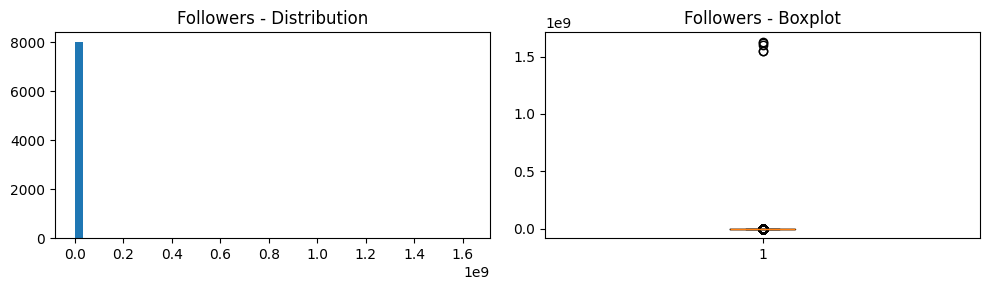

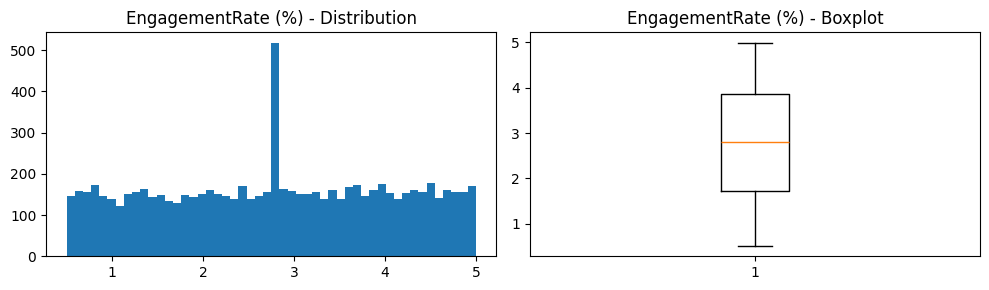

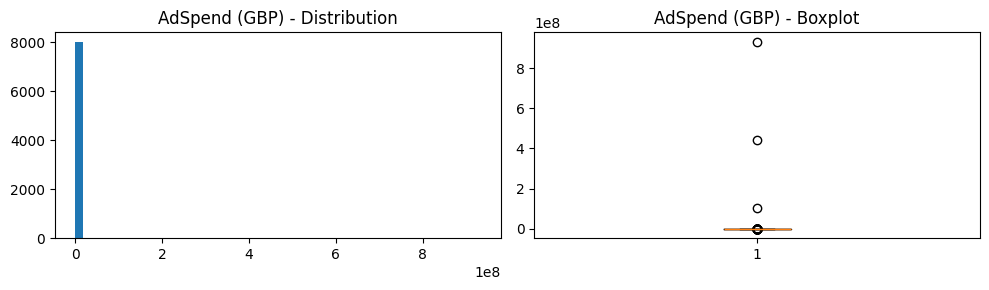

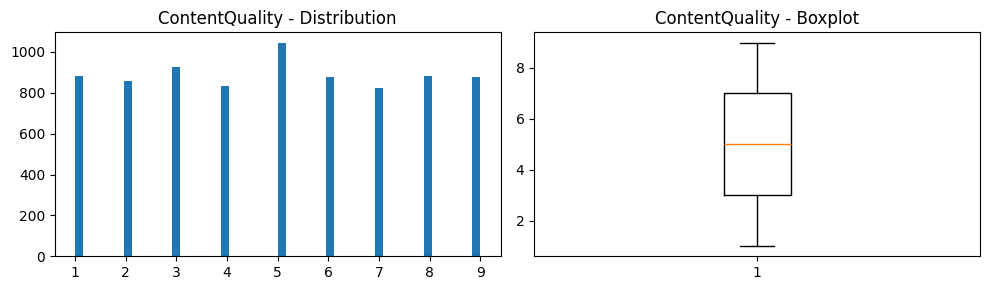

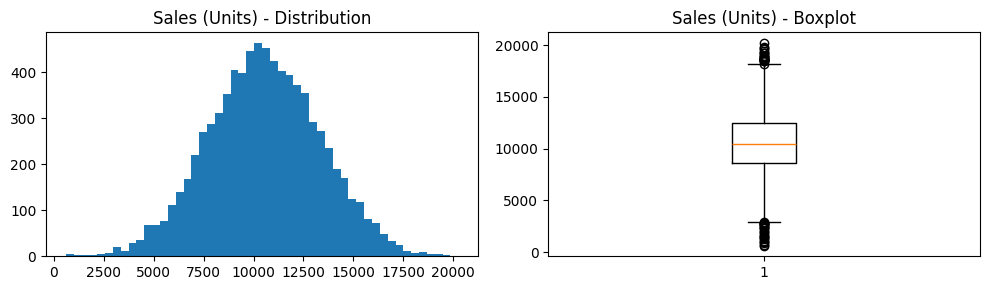

In [ ]:
import matplotlib.pyplot as plt

# Plot Histogram and Boxplot of all the numerical features in the dataset
import matplotlib.pyplot as plt

cols = ['Followers', 'EngagementRate (%)', 'AdSpend (GBP)', 'ContentQuality', 'Sales (Units)']

for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].hist(train[col], bins=50)
    axes[0].set_title(f'{col} - Distribution')
    axes[1].boxplot(train[col].dropna())
    axes[1].set_title(f'{col} - Boxplot')
    plt.tight_layout()
    save_img = f"{col}.png"
    plt.savefig(save_img)
    plt.show()




In [ ]:
adspend_sorted = train.sort_values('AdSpend (GBP)', ascending=False)
print(adspend_sorted[['ID', 'AdSpend (GBP)']].head(5))

        ID  AdSpend (GBP)
3953  3811   9.322339e+08
5174   155   4.414560e+08
7993   466   1.016000e+08
5914  3804   1.000000e+04
4462  1035   1.000000e+04


In [ ]:
print(len(train))
print(train.duplicated().sum())
print(train['EngagementRate (%)'].describe())

8000
0
count    8000.000000
mean        2.783001
std         1.274258
min         0.501136
25%         1.717967
50%         2.801690
75%         3.862437
max         4.999662
Name: EngagementRate (%), dtype: float64


In [ ]:
spike_rows = train[(train['EngagementRate (%)'] > 2.7) & (train['EngagementRate (%)'] < 2.85)]
print(spike_rows[['Notes']].value_counts())

Notes  
Unknown    199
Check      111
Good       110
Review     108
Pending    102
Name: count, dtype: int64


In [ ]:
# Re-load and check BEFORE imputing, to see the "true" spike untouched by your fill values
raw_eng = pd.to_numeric(pd.read_csv('/content/messy_train_data.csv')['EngagementRate (%)'].astype(str).str.replace('%',''), errors='coerce')
raw_spike = raw_eng[(raw_eng > 2.7) & (raw_eng < 2.85)]
print(len(raw_spike))  # should be close to 273, the count from the ORIGINAL data

273


In [ ]:
min_adspend = train['AdSpend (GBP)'].min()

print(f"Min AdSpend: {min_adspend:.4f}")

Min AdSpend: 1000.0000


### Observation:
* We see 3 top rows in the **AdSpend (GBP)** as £101 million, £441 million, and £932 million. No real campaign would spend hundreds of millions of pounds when the typical spend is a few thousand.
* ContentQuality's spread is uniform and no outliers have been detected for this column therefore we can leave it as is.
* Engagement Rate is fairly uniformly distribued however has shown a peculiar spike at 2.7 to 2.8 clustering around ```630`` rows.
* Followers has everything compressed to zero and having followers count 100 muillions to billions which is not real.      
* Sales look normally distributed with highest point of the distribution around ```10,000 to 10,500 units```. The median or the 50th percentile sits near 10000 units. The lower quatile is at 8500 and upper quartile around 12,500 units. The whisker's boundary representing the outliers of the data is below 3000 and 18,000 units. We decided not the cap the outliers as they show the low or high performing campaigns

### Action
* Followers: Cap using IQR — lower bound = Q1 − 1.5×IQR, upper bound = Q3 + 1.5×IQR
  (lower fence ≈ 15,208 — no real values fall below this, so no change at the low end;
  upper fence ≈ 182,660 — caps the 5 extreme rows in the hundreds of millions to billions)
* AdSpend: Cap using IQR — lower bound = Q1 − 1.5×IQR, upper bound = Q3 + 1.5×IQR
  (lower fence ≈ £933 — the outlier values fall below this and get capped up;
  upper fence ≈ £9,047 — caps the 3 extreme multi-million-pound rows)
* Engagement Rate shows a spike around 2.7–2.8 (~630 rows in the current cleaned data);
  note that part of this count is inflated by median imputation of missing/invalid values
  landing in this band — the spike in the original raw data is closer to ~273 rows,
  and is spread proportionally across all Notes categories rather than tied to one status.
* ContentQuality: No action needed as no outlier detected.
* Sales: No action needed as distribution is nearly normal.

In [ ]:
for col in ['Followers', 'AdSpend (GBP)']:
  q1 = train[col].quantile(0.25)
  q3 = train[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)

### High and low performing campaigns using "Quantiles"
* A quantile will split the data into equal sized chunk, 75th percentile will find the sales values where 75% of the campaigns sold less and 25% sold more.We use quantile to find high and low performers as using a fixed number is arbitrary.
* To calculate the percentage difference we subtract lower performers by high performers to get the gap and then divide by low to convert this gap into a relative percentage to compare it across different columns.     

In [ ]:
# Split data into top and bottom
q75 = train['Sales (Units)'].quantile(0.75)
q25 = train['Sales (Units)'].quantile(0.25)

high_performers = train[train['Sales (Units)'] >= q75]
low_performers = train[train['Sales (Units)'] <= q25]

print(f'High performers: {len(high_performers)} rows, Low performers: {len(low_performers)} rows')

High performers: 2001 rows, Low performers: 2000 rows


In [ ]:
comparison = pd.DataFrame(
    {'High Performers (mean)': high_performers[['Followers','EngagementRate (%)','AdSpend (GBP)','ContentQuality']].mean(),
     'Low Performers (mean)': low_performers[['Followers','EngagementRate (%)','AdSpend (GBP)','ContentQuality']].mean()}
)
comparison['% Difference'] = ((comparison['High Performers (mean)'] - comparison['Low Performers (mean)']) / comparison['Low Performers (mean)']) * 100
print(comparison)

                    High Performers (mean)  Low Performers (mean)  \
Followers                    117868.899550           77828.046062   
EngagementRate (%)                2.917310               2.665398   
AdSpend (GBP)                  5761.071888            4284.346713   
ContentQuality                    5.511244               4.416000   

                    % Difference  
Followers              51.447846  
EngagementRate (%)      9.451193  
AdSpend (GBP)          34.467919  
ContentQuality         24.801730  


### Doing a t-test to make sure that our differences are statistically real

In [ ]:
from scipy import stats

for col in ['Followers','EngagementRate (%)','AdSpend (GBP)','ContentQuality']:
  t_stat, p_val = stats.ttest_ind(high_performers[col], low_performers[col], equal_var=False)
  print(f'{col}: t={t_stat:.2f}, p={p_val:.4f}', '→ significant' if p_val < 0.05 else '→ not significant')


Followers: t=44.24, p=0.0000 → significant
EngagementRate (%): t=6.31, p=0.0000 → significant
AdSpend (GBP): t=34.51, p=0.0000 → significant
ContentQuality: t=13.74, p=0.0000 → significant


For all 4 features the t_test is significant at p_value < 0.05 allowing us to reject the null hypothesis meaning the difference being observed between high performing and low performing campaigns are statistically significant and not due to random chance. The bigger t_value derived shows a clear separation between the high and low performer groups.  

/tmp/ipykernel_1002/3183325449.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([high_performers[col], low_performers[col]], labels=['High', 'Low'])
/tmp/ipykernel_1002/3183325449.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([high_performers[col], low_performers[col]], labels=['High', 'Low'])
/tmp/ipykernel_1002/3183325449.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([high_performers[col], low_performers[col]], labels=['High', 'Low'])
/tmp/ipykernel_1002/3183325449.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed '

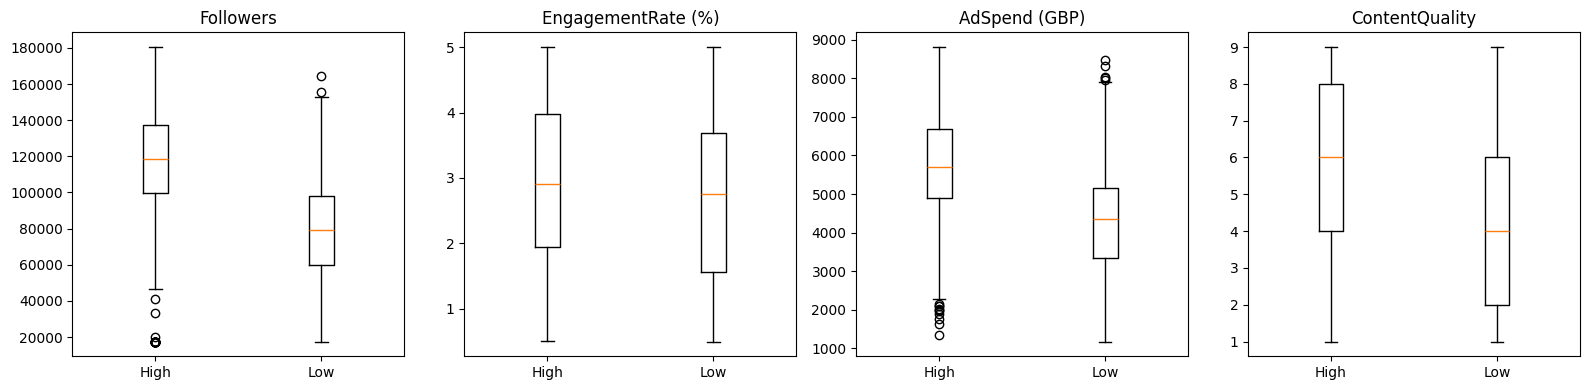

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(['Followers','EngagementRate (%)','AdSpend (GBP)','ContentQuality']):
    axes[i].boxplot([high_performers[col], low_performers[col]], labels=['High', 'Low'])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
top_campaigns = train.sort_values('Sales (Units)', ascending=False).head(5)
bottom_campaigns = train.sort_values('Sales (Units)', ascending=True).head(5)

cols = ['ID','Followers','EngagementRate (%)','AdSpend (GBP)','ContentQuality','Sales (Units)']
print('Top 5 performing campaigns:')
print(top_campaigns[cols])
print('\nBottom 5 performing campaigns:')
print(bottom_campaigns[cols])


Top 5 performing campaigns:
        ID   Followers  EngagementRate (%)  AdSpend (GBP)  ContentQuality  \
1942  4328  150983.000            2.912254    5165.161379               7   
7752  5539  128573.000            3.746613    8811.133786               1   
2752  5157  180450.375            3.714186    6667.064133               7   
4107  7441  180450.375            2.562862    5496.279317               5   
4105  7766  177964.000            3.241608    7539.070150               9   

      Sales (Units)  
1942          20263  
7752          19789  
2752          19718  
4107          19657  
4105          19398  

Bottom 5 performing campaigns:
        ID  Followers  EngagementRate (%)  AdSpend (GBP)  ContentQuality  \
922   2880    32853.0            0.600552    1924.791436               1   
1417  2266    46642.0            0.822428    1173.770813               8   
7737  6944    46174.0            0.593438    5005.219030               1   
6599  7813    88051.0            0.895353

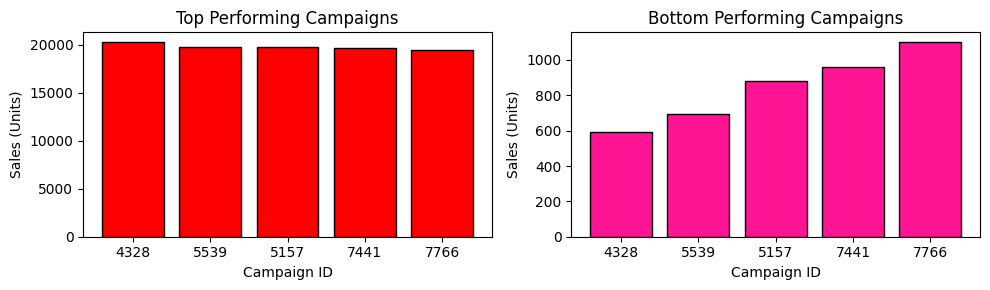

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))


axes[0].bar(top_campaigns['ID'].astype(str), top_campaigns['Sales (Units)'], color='red', edgecolor='black')
axes[0].set_title('Top Performing Campaigns')
axes[0].set_xlabel('Campaign ID')
axes[0].set_ylabel('Sales (Units)')

axes[1].bar(top_campaigns['ID'].astype(str), bottom_campaigns['Sales (Units)'], color='deeppink', edgecolor='black')
axes[1].set_title('Bottom Performing Campaigns')
axes[1].set_xlabel('Campaign ID')
axes[1].set_ylabel('Sales (Units)')
plt.tight_layout()
plt.show()

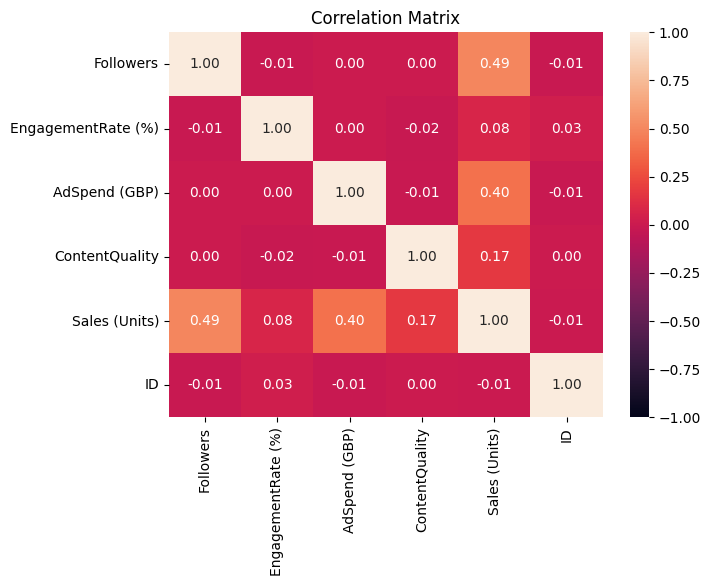

In [ ]:
corrs_cols = train.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = train[corrs_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='rocket', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Bucket AdSpend into decile and check if returns flatten at the high end
train['AdSpend_decile'] = pd.qcut(train['AdSpend (GBP)'], q=10, duplicates='drop')
decile_mean = train.groupby('AdSpend_decile')['Sales (Units)'].mean()
print(decile_mean,"\n")
print(decile_mean.diff())

AdSpend_decile
(1173.77, 3127.571]      8570.215000
(3127.571, 3780.081]     9315.271250
(3780.081, 4274.493]     9857.968750
(4274.493, 4698.258]    10265.033750
(4698.258, 5005.219]    10404.707441
(5005.219, 5286.544]    10715.287561
(5286.544, 5718.256]    10900.842500
(5718.256, 6196.448]    11227.680000
(6196.448, 6864.674]    11616.775000
(6864.674, 8811.134]    12643.231250
Name: Sales (Units), dtype: float64 

AdSpend_decile
(1173.77, 3127.571]             NaN
(3127.571, 3780.081]     745.056250
(3780.081, 4274.493]     542.697500
(4274.493, 4698.258]     407.065000
(4698.258, 5005.219]     139.673691
(5005.219, 5286.544]     310.580119
(5286.544, 5718.256]     185.554939
(5718.256, 6196.448]     326.837500
(6196.448, 6864.674]     389.095000
(6864.674, 8811.134]    1026.456250
Name: Sales (Units), dtype: float64


/tmp/ipykernel_1002/1354322946.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_mean = train.groupby('AdSpend_decile')['Sales (Units)'].mean()


In [ ]:
# Bucket Followers into deciles and check if returns flatten at the high end
train['Followers_decile'] = pd.qcut(train['Followers'], q=10, duplicates='drop')
follower_decile_means = train.groupby('Followers_decile')['Sales (Units)'].mean()
print(follower_decile_means,"\n")
print(follower_decile_means.diff())

Followers_decile
(17503.374, 57771.2]       8242.663750
(57771.2, 73289.2]         8917.830000
(73289.2, 83341.0]         9443.880150
(83341.0, 92038.4]         9993.415519
(92038.4, 99120.5]        10309.375000
(99120.5, 106271.0]       10610.727778
(106271.0, 114742.3]      11079.722500
(114742.3, 124543.8]      11602.351250
(124543.8, 137689.3]      12174.718750
(137689.3, 180450.375]    13102.881250
Name: Sales (Units), dtype: float64 

Followers_decile
(17503.374, 57771.2]             NaN
(57771.2, 73289.2]        675.166250
(73289.2, 83341.0]        526.050150
(83341.0, 92038.4]        549.535370
(92038.4, 99120.5]        315.959481
(99120.5, 106271.0]       301.352778
(106271.0, 114742.3]      468.994722
(114742.3, 124543.8]      522.628750
(124543.8, 137689.3]      572.367500
(137689.3, 180450.375]    928.162500
Name: Sales (Units), dtype: float64


/tmp/ipykernel_1002/2846949839.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  follower_decile_means = train.groupby('Followers_decile')['Sales (Units)'].mean()


In [ ]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

features = ['Followers','EngagementRate (%)','AdSpend (GBP)','ContentQuality']
X_scaled = StandardScaler().fit_transform(train[features])
X_scaled = sm.add_constant(X_scaled)
model_scaled = sm.OLS(train['Sales (Units)'], X_scaled).fit()
print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:          Sales (Units)   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     1594.
Date:                Sat, 18 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:47:25   Log-Likelihood:                -72528.
No. Observations:                8000   AIC:                         1.451e+05
Df Residuals:                    7995   BIC:                         1.451e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.054e+04     23.423    450.184      0.0

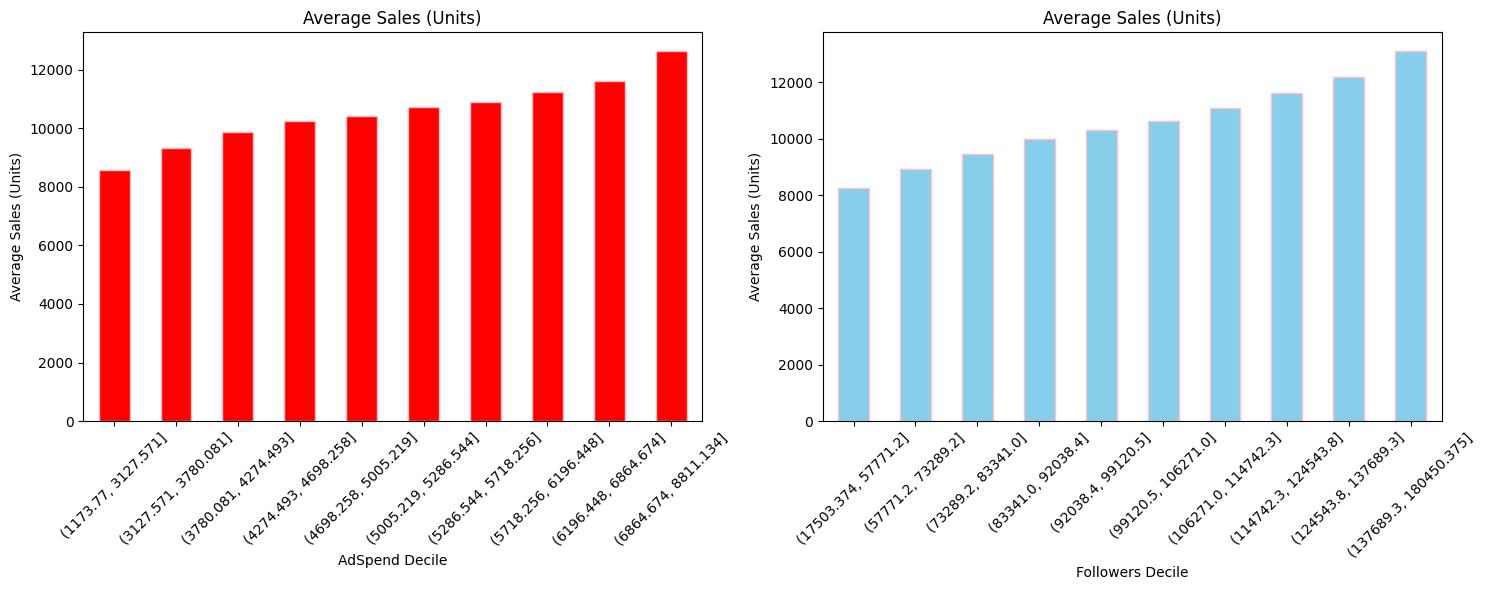

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

decile_mean.plot(kind='bar', color='red', edgecolor='pink', title='Avg Sales by AdSpend Decile', ax=axes[0])
axes[0].set_title('Average Sales (Units)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('AdSpend Decile')
axes[0].set_ylabel('Average Sales (Units)')

follower_decile_means.plot(kind='bar', color='skyblue', edgecolor='pink', title='Avg Sales by Followers Decile', ax=axes[1])
axes[1].set_title('Average Sales (Units)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('Followers Decile')
axes[1].set_ylabel('Average Sales (Units)')

plt.tight_layout()
plt.show()

# Conclusion from Section B

* **Correlation ranking:** `Followers` and `AdSpend` are the strongest drivers of Sales, followed by a moderately weaker relationship with `ContentQuality`. `EngagementRate` barely correlates with Sales at `0.08`, suggesting it plays a minimal direct role.

* **AdSpend decile analysis — no diminishing returns:** Step-wise increases in average Sales shrink from £745 to £140 through the middle deciles (2 through 5), suggesting slowing returns at that stage. However, the step sizes bounce back up afterward, and the **final decile shows the single largest jump of all ten buckets — an increase of +£1,026** at the highest spending bracket. This indicates Sales *accelerate* at the top of the spending range — high-spend campaigns are getting the best payoff per pound, not the worst.

* **Followers decile analysis — steady, linear growth:** Unlike AdSpend, the Followers decile breakdown shows a roughly linear, steady increase in average Sales moving up the ladder, with no sharp acceleration or diminishing pattern at either extreme.

* **OLS Regression — model fit:** The 4-feature OLS model explains 44.4% of the variation in Sales (R² = 0.444). The remaining ~56% is attributable to factors outside this dataset.

* **OLS Regression — overall significance:** F-statistic = 1594, Prob(F-statistic) = 0.00. This tests whether the model as a whole outperforms simply predicting the average Sales every time — the near-zero p-value confirms the model has genuine predictive power, not noise.

* **Durbin-Watson = 1.984** — close to the ideal value of 2.0, confirming no significant autocorrelation in the residuals. This reinforces the finding that this is cross-sectional data, not time-series data.

* **Raw coefficient interpretation — Followers:** A coefficient of 0.0435 means each additional single follower adds 0.0435 units of Sales. Scaled up, every increase of 10,000 followers corresponds to roughly 435 additional Sales units.

* **Multicollinearity check resolved:** The original OLS model flagged a high condition number (5.81e+05), typically a sign of multicollinearity. Re-running the regression on standardized (scaled) features reduced the condition number to **1.02** — confirming the original warning was a scale artifact caused by features with very different units/ranges, not genuine redundancy between predictors. `Followers`, `EngagementRate`, `AdSpend`, and `ContentQuality` are independent drivers of Sales.

* **Standardized coefficients — which feature matters most:** With all features placed on a comparable scale, the ranking of effect size on Sales is:

| Feature | Standardized coefficient |
|---|---|
| Followers | 1387.6 |
| AdSpend | 1140.1 |
| ContentQuality | 482.0 |
| EngagementRate | 240.7 |

This confirms the same ordering seen in the raw correlation matrix, now expressed on a directly comparable scale — strengthening confidence that the ranking is real and not an artifact of differing units.

* **ContentQuality — a low-cost, high-leverage lever:** ContentQuality shows a strong, actionable effect on Sales and, unlike Followers or AdSpend, can be improved directly through creator coaching rather than requiring additional budget or organic audience growth — making it an efficient, low-cost intervention point.

* **Budget allocation — revised recommendation:** Decile analysis shows Sales accelerate most at the highest AdSpend bracket, suggesting that increasing investment in already high-performing campaigns may yield the strongest marginal return, rather than reallocating budget away from them toward low performers, as originally assumed.

* **Correlational limits and next step:** These relationships are correlational, not causal. Before committing to any budget reallocation or content-coaching program, a controlled **A/B test** is recommended — randomly assigning a subset of campaigns to the proposed intervention (e.g., increased budget, or content coaching) versus a control group — to confirm actual causal impact rather than relying on observed association alone.

# Section C: Feature Engineering
### Goal
* Create better input features that improve the predictive power of your model.
### Hints
* Think about whether raw values are the best representation of campaign impact or if transformations could make relationships clearer.
* Consider interactions between variables (for example, how engagement and followers together may influence sales).
* Be mindful of feature scale differences and how they may affect model behavior.
* Feature engineering decisions should be driven by both data patterns and marketing intuition.


In [ ]:
train.head()

,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,Sales (Units),ID,Timestamp,Notes,AdSpend_decile,Followers_decile
0,106572.0,2.573175,2614.378195,5,6340,9254,2021-11-27,Pending,"(1173.77, 3127.571]","(106271.0, 114742.3]"
1,77583.0,0.939498,4975.962514,8,5793,1561,2022-02-13,Review,"(4698.258, 5005.219]","(73289.2, 83341.0]"
2,92832.0,2.176101,4107.769534,6,8104,1670,2023-09-25,Pending,"(3780.081, 4274.493]","(92038.4, 99120.5]"
3,53565.0,1.478376,4293.330465,4,7293,6087,2023-02-15,Review,"(4274.493, 4698.258]","(17503.374, 57771.2]"
4,121079.0,3.374198,5343.549441,3,14396,6669,2023-05-28,Unknown,"(5286.544, 5718.256]","(114742.3, 124543.8]"


In [ ]:
train['Engagement_x_ContentQuality'] = train['EngagementRate (%)'] * train['ContentQuality']
train['Engagement_x_Followers'] = train['EngagementRate (%)'] * train['Followers']
train['ContentQuality_x_Followers'] = train['ContentQuality'] * train['Followers']
train['AdSpend_x_Followers'] = train['AdSpend (GBP)'] * train['Followers']

We created 4 new features trying different feature combination.Now we check them for collinearity.

In [ ]:
# Check how each new feature correlates with Sales, and with its own components
new_features = ['Engagement_x_ContentQuality', 'Engagement_x_Followers', 'ContentQuality_x_Followers', 'AdSpend_x_Followers']
print(train[new_features + ['Sales (Units)']].corr()['Sales (Units)'])

# Check for correlation with original components
print("\n",train[['Followers','AdSpend (GBP)','AdSpend_x_Followers']].corr())

Engagement_x_ContentQuality    0.163006
Engagement_x_Followers         0.337663
ContentQuality_x_Followers     0.388333
AdSpend_x_Followers            0.622247
Sales (Units)                  1.000000
Name: Sales (Units), dtype: float64

                      Followers  AdSpend (GBP)  AdSpend_x_Followers
Followers             1.000000       0.001826             0.735182
AdSpend (GBP)         0.001826       1.000000             0.646093
AdSpend_x_Followers   0.735182       0.646093             1.000000


In [ ]:
# Center variables before creating the interaction — reduces multicollinearity
followers_centered = train['Followers'] - train['Followers'].mean()
adspend_centered = train['AdSpend (GBP)'] - train['AdSpend (GBP)'].mean()
engagement_rate_centered = train['EngagementRate (%)'] - train['EngagementRate (%)'].mean()
content_quality_centered = train['ContentQuality'] - train['ContentQuality'].mean()
train['Engagement_x_Followers_centered'] = followers_centered * engagement_rate_centered
train['ContentQuality_x_Followers_centered'] = content_quality_centered * followers_centered
train['AdSpend_x_Followers_centered'] = followers_centered * adspend_centered

In [ ]:
# Check for correlation with original components
print(train[['Followers','AdSpend (GBP)','AdSpend_x_Followers_centered']].corr())
print("\n",train[['Followers','EngagementRate (%)','Engagement_x_Followers_centered']].corr())
print("\n",train[['Followers','ContentQuality','ContentQuality_x_Followers_centered']].corr())

                              Followers  AdSpend (GBP)  \
Followers                      1.000000       0.001826   
AdSpend (GBP)                  0.001826       1.000000   
AdSpend_x_Followers_centered   0.020993      -0.003138   

                              AdSpend_x_Followers_centered  
Followers                                         0.020993  
AdSpend (GBP)                                    -0.003138  
AdSpend_x_Followers_centered                      1.000000  

                                  Followers  EngagementRate (%)  \
Followers                         1.000000           -0.012835   
EngagementRate (%)               -0.012835            1.000000   
Engagement_x_Followers_centered   0.000525           -0.002426   

                                 Engagement_x_Followers_centered  
Followers                                               0.000525  
EngagementRate (%)                                     -0.002426  
Engagement_x_Followers_centered                        

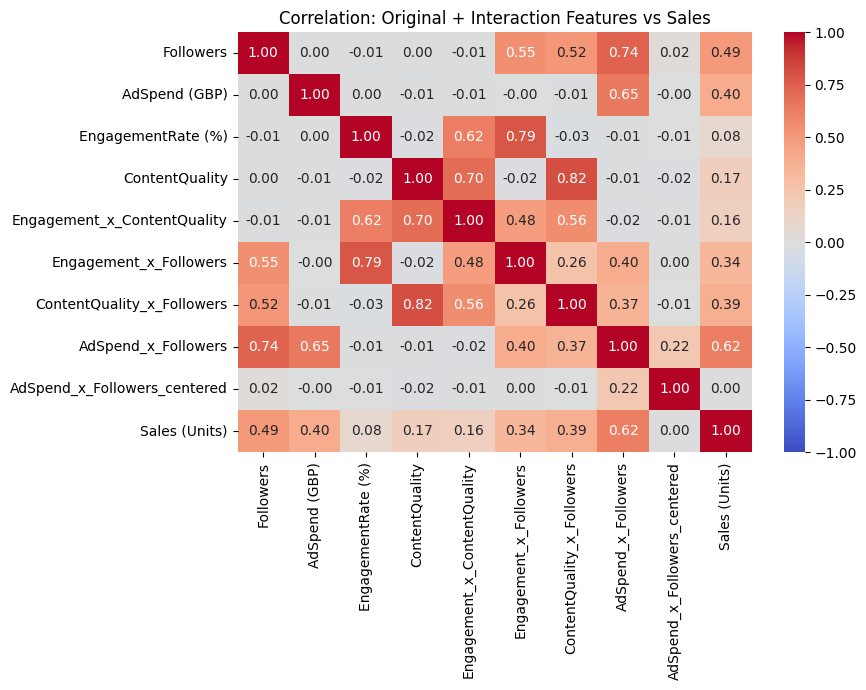

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['Followers','AdSpend (GBP)','EngagementRate (%)','ContentQuality',
        'Engagement_x_ContentQuality','Engagement_x_Followers',
        'ContentQuality_x_Followers','AdSpend_x_Followers','AdSpend_x_Followers_centered','Sales (Units)']

plt.figure(figsize=(9,7))
sns.heatmap(train[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Original + Interaction Features vs Sales')
plt.tight_layout()
plt.show()

In [ ]:
train = train.drop(columns=['Engagement_x_ContentQuality',
       'Engagement_x_Followers', 'ContentQuality_x_Followers',
       'AdSpend_x_Followers', 'Engagement_x_Followers_centered',
       'ContentQuality_x_Followers_centered', 'AdSpend_x_Followers_centered', 'AdSpend_decile', 'Followers_decile'])

In [ ]:
train.head()

,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,Sales (Units),ID,Timestamp,Notes
0,106572.0,2.573175,2614.378195,5,6340,9254,2021-11-27,Pending
1,77583.0,0.939498,4975.962514,8,5793,1561,2022-02-13,Review
2,92832.0,2.176101,4107.769534,6,8104,1670,2023-09-25,Pending
3,53565.0,1.478376,4293.330465,4,7293,6087,2023-02-15,Review
4,121079.0,3.374198,5343.549441,3,14396,6669,2023-05-28,Unknown


### Running and Anova test on Notes

In [ ]:
from scipy import stats

# Split sales into two groups, one per Notes category
groups = [train[train['Notes']==category]['Sales (Units)'] for category in train['Notes'].unique()]

# Initiating One-way ANOVA: tests whether mean Sales differs significantly across Notes categories
f_stat, p_value = stats.f_oneway(*groups)

print(f'ANOVA F-statistic: {f_stat:.2f}')
print(f'ANOVA p-value: {p_value:.4f}')

if p_value < 0.05:
  print('-> Significant difference in Sales across Notes categories - consider including Notes as a feature')
else:
  print('-> No significant difference in Sales across Notes categories - Notes can likely be excluded.')


ANOVA F-statistic: 1.59
ANOVA p-value: 0.1751
-> No significant difference in Sales across Notes categories - Notes can likely be excluded.


In [ ]:
print(train.groupby('Notes')['Sales (Units)'].agg(['mean', 'median', 'count']))

                 mean   median  count
Notes                                
Check    10677.273196  10547.0   1358
Good     10492.953632  10379.0   1294
Pending  10425.931968  10497.0   1367
Review   10519.674191  10410.0   1329
Unknown  10575.746606  10599.0   2652


# Conclusion from Section C
* Four candidate interaction features were engineered and tested (Engagement×ContentQuality, Engagement×Followers, ContentQuality×Followers, AdSpend×Followers). Initial correlations suggested AdSpend×Followers might add value, but centering the component variables before multiplying — the correct approach for isolating genuine interaction effects — reduced its correlation with Sales to 0.00, indicating no true synergistic effect exists beyond the two features' independent, additive contributions. All four interaction terms were therefore excluded from the final feature set; Followers and AdSpend continue to be included as independent predictors.
* Basis the ANOVA test we exclude ``Notes`` from our feature selection proces. Our ``H0`` stated that all Notes categories have same average Sales meaning Notes has no effect on the contrary ``H1 (alternative hypothesis)`` stated that at least one Notes category has a genuinely difefrent average Sales. The p_value was >= 0.05 (alpha) meaning there is no evidence Notes matters to drive the Sales.   

# Section D: Model Building
### Goal
* Train a regression model that can predict sales from campaign attributes.
### Hints
* Start with a simple baseline model before exploring more complex options.
* Ensure your model can handle noisy and imperfect real-world data.
* Use appropriate validation strategies to avoid overfitting.
* The focus should be on building a model that generalizes well, not just one
that performs well on training data.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Define features and target variable
features = ['Followers', 'EngagementRate (%)', 'AdSpend (GBP)', 'ContentQuality']

X = train[features]
y = train['Sales (Units)']

# Split the model
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

def evaluate(name, model, X_tr, X_val, y_tr, y_val):
  model.fit(X_tr, y_tr)
  preds = model.predict(X_val)
  print(f"{name:20s} | R2: {r2_score(y_val, preds):.4f} MAE={mean_absolute_error(y_val, preds):.1f} RMSE={np.sqrt(mean_squared_error(y_val, preds)):.1f}")

evaluate('Baseline (Linear)', LinearRegression(), X_tr, X_val, y_tr, y_val)
evaluate('Complex (Random Forest)', RandomForestRegressor(n_estimators=200, random_state=42), X_tr, X_val, y_tr, y_val)


Baseline (Linear)    | R2: 0.4096 MAE=1701.3 RMSE=2166.0
Complex (Random Forest) | R2: 0.3852 MAE=1753.8 RMSE=2210.2


In [ ]:
X_val.isnull().sum()

,0
Followers,0
EngagementRate (%),0
AdSpend (GBP),0
ContentQuality,0


### Verifying Random Forest for Overfitting

In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_tr, y_tr)
print('Train R²:', rf.score(X_tr, y_tr))
print('Val R²:', rf.score(X_val, y_val))

Train R²: 0.9212772087521769
Val R²: 0.3852125911188278


In [ ]:
lr = LinearRegression()
lr.fit(X_tr, y_tr)
print('Train R²:', lr.score(X_tr, y_tr))
print('Val R²:', lr.score(X_val, y_val))

Train R²: 0.45211751547834944
Val R²: 0.40957949227360013


### Bagging Overfitting - Causes & Mitigation  

* The RF model performed extremely well on training data with r2_score ``0.92`` but on validation it could only output ``0.39``.
* This has happened because in Bagging trees grow deep and each tree keep splitting until it isolates very small, specific groups of training rows. With enough depth, a tree can carve out a leaf for almost every indivudual data point, which drive training R2 sky-high but tells us nothing useful about new data as it memorizes noise not signal.
* We will now regularize the RF and see if a properly constrained version can beat the baseline.

In [ ]:
X_val.isnull().sum()

,0
Followers,0
EngagementRate (%),0
AdSpend (GBP),0
ContentQuality,0


In [ ]:
rf_regularized = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

rf_regularized.fit(X_tr, y_tr)
print('Train R²:', rf_regularized.score(X_tr, y_tr))
print('Val R²:', rf_regularized.score(X_val, y_val))

Train R²: 0.5032356366605629
Val R²: 0.4257931182781567


In [ ]:
rf_preds = rf_regularized.predict(X_val)
print('Final test performance:')
print('MAE:', mean_absolute_error(y_val, rf_preds))
print('RMSE:', np.sqrt(mean_squared_error(y_val, rf_preds)))

Final test performance:
MAE: 1698.2128824847168
RMSE: 2136.017803040023


# Conclusion Section D
* LR initially outperformed RF due to overfitting however, after tuning the hyperparameters Random Forest has gave us better results with Train R² (0.503) vs Validation R² (0.426).
* We can now move to the final stage of model selection. The regularized Random Forest has beaten Linear Regression model in all the aspects (R2_Score, MAE & RMSE) therefore we select ``Regularized Random Forest`` as our final model.  


# Section E: Model Evaluation & Tuning
### Goal
* Evaluate how well your model performs and improve its reliability.
### Hints
* Use error-based metrics to understand how far predictions are from actual sales values.
* Compare model performance across different configurations to identify meaningful improvements.
* Pay attention to consistency of results across validation folds rather than a single score.
* This section is about model robustness, not just maximizing performance numbers.


### Cross Validation for Consistency (Robustness)
Rather than relying on single train/test/split we use cross validation split to ensure that our model perform consistently across different subsets of data.

In [ ]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare full training data matrices
X_train_full = pd.concat([X_tr, X_val])
y_train_full = pd.concat([y_tr, y_val])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. CRITICAL FIX: Explicitly clone the model structure for CV
# This creates a brand new object so the original rf_regularized stays untouched!
cv_rf = clone(rf_regularized)

# Evaluate R2 using the cloned model
cv_r2_scores = cross_val_score(cv_rf, X_train_full, y_train_full, cv=kf, scoring='r2')
print(f'Cross-validated R2 scores: {cv_r2_scores}')
print(f"Mean R²: {cv_r2_scores.mean():.4f}")
print(f"Standard Deviation: {cv_r2_scores.std():.4f}")

Cross-validated R2 scores: [0.4196088  0.45570778 0.46104602 0.47048167 0.43570688]
Mean R²: 0.4485
Standard Deviation: 0.0184


The standard deviation for our model is < 0.05 ``0.0184`` which is not stable and **NOT** overly sensistive to how the data split.

### Visualizing the Errors

Honest Validation MAE: 1698.21
Honest Validation RMSE: 2136.02


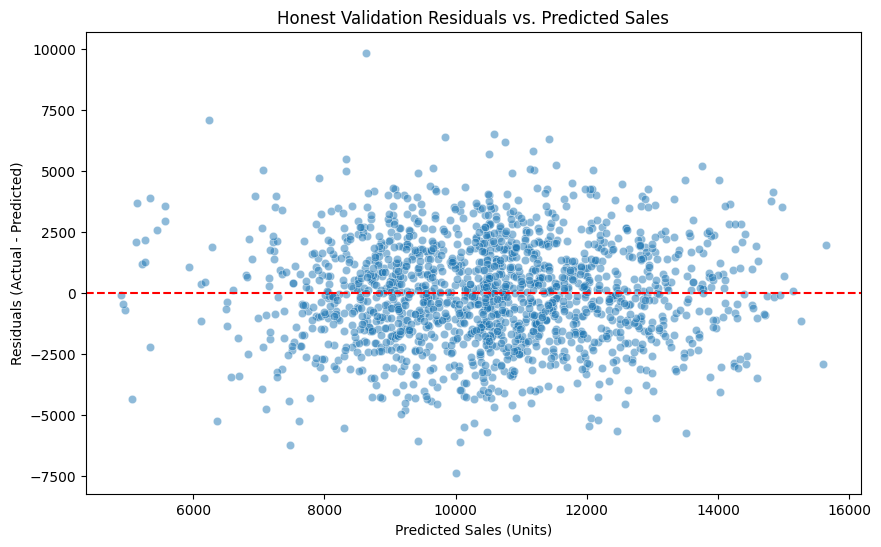

In [ ]:
rf_regularized.fit(X_tr, y_tr)
y_val_pred = rf_regularized.predict(X_val)

mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f'Honest Validation MAE: {mae_val:.2f}')
print(f'Honest Validation RMSE: {rmse_val:.2f}')

# 4. Generate the honest residual plot
residuals = y_val - y_val_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sales (Units)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Honest Validation Residuals vs. Predicted Sales')
plt.show()

### Hyperparameter Tuning:
Previously we selected max_depth=6 and min_sample_leaf=20 manually. Now we will use GridSearchCV to see a slightly if different configuration yields a better and a more stable validation score without reverting to overfitting.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [15, 20, 30],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train_full, y_train_full)

print("Best parameters found: ", grid_search.best_params_)
print("Best MAE score found: ", -grid_search.best_score_)

Best parameters found:  {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'n_estimators': 200}
Best MAE score found:  -1648.000975906337


In [ ]:
print("Best MAE score found: ", -grid_search.best_score_)

Best MAE score found:  1648.000975906337


The hyperparameter tuned **grid_search** reduced the MAE from ``1698.21`` to ``1648.000975906337``. Therefore, we will using the RF with the latest hyperparameters found in the gridsearch CV to predict the final sales units.  

In [ ]:
# 1. Save Training Medians (Perfect as-is)
train_medians = {
    'EngagementRate (%)': train['EngagementRate (%)'].median(),
    'AdSpend (GBP)': train['AdSpend (GBP)'].median(),
    'ContentQuality': train['ContentQuality'].median(),
    'Followers': train['Followers'].median()
}

# 2. Save Training Outlier Bounds directly from the already-capped min/max
train_bounds = {}
for col in ['Followers', 'AdSpend (GBP)']:
    train_bounds[col] = {
        'lower': train[col].min(),  # The lowest value allowed in train
        'upper': train[col].max()   # The highest value allowed in train
    }

# 1. Isolate the test features
X_test_final = test[['Followers', 'EngagementRate (%)', 'AdSpend (GBP)', 'ContentQuality']].copy()

# 2. FIRST: Force all columns to be strictly numeric, turning dirty strings into NaNs
for col in X_test_final.columns:
    X_test_final[col] = pd.to_numeric(X_test_final[col], errors='coerce')

# 3. SECOND: Impute the newly exposed NaNs using your SAVED TRAIN MEDIANS
for col in X_test_final.columns:
    X_test_final[col] = X_test_final[col].fillna(train_medians[col])

# 4. THIRD: Safe type casting
X_test_final['ContentQuality'] = X_test_final['ContentQuality'].astype(int)

# 5. FOURTH: Cap outliers using the SAVED TRAIN MIN/MAX walls
for col in ['Followers', 'AdSpend (GBP)']:
    lower_limit = float(train_bounds[col]['lower'])
    upper_limit = float(train_bounds[col]['upper'])
    X_test_final[col] = X_test_final[col].clip(lower=lower_limit, upper=upper_limit)

# Final Verification Check
print("Missing values in processed test features:\n", X_test_final.isnull().sum())

from sklearn.ensemble import RandomForestRegressor

# 1. Instantiate the final model using the exact GridSearchCV parameters
final_production_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    max_features='sqrt',
    min_samples_leaf=15,
    random_state=42
)

# 2. Fit on the full training dataset (X and y combine X_tr and X_val)
final_production_model.fit(X, y)
# 3. Predict on the cleaned test features
final_preds = final_production_model.predict(X_test_final)

# 4. Attach metadata and predictions to a clean submission dataframe
submission_df = X_test_final.copy()
submission_df['ID'] = test['ID']
submission_df['Timestamp'] = test['Timestamp']
submission_df['Notes'] = test['Notes'].fillna('Unknown')
submission_df['Predicted Sales (Units)'] = final_preds

# 5. Export to CSV
submission_df.to_csv('predictions.csv', index=False)

print("Final predictions exported successfully! Shape:", submission_df.shape)
print("Missing values in final file:\n", submission_df.isnull().sum())

Missing values in processed test features:
 Followers             0
EngagementRate (%)    0
AdSpend (GBP)         0
ContentQuality        0
dtype: int64
Final predictions exported successfully! Shape: (2000, 8)
Missing values in final file:
 Followers                  0
EngagementRate (%)         0
AdSpend (GBP)              0
ContentQuality             0
ID                         0
Timestamp                  0
Notes                      0
Predicted Sales (Units)    0
dtype: int64


# Conclusion Section E

* To squeeze maximum performace out of the Random Forest architecture without inducing overfitting, a systematic grid search was performed over ``max_depth``, ``max_features`` and ``min_sample_leaf``.
* The search isolated the ideal configuration as: ``n_estimators:200``, ``max_depth: 8``, ``max_features:'sqrt'`` and ``min_samples_leaf:15``.
* This optimization successfully reduced the true validation MAE from **16.98.21** down to **1648.00**. This demonstrates that constraining the feature susets per split (sqrt) and increasing the minimum leaf size structure effectively smoothed out remaining noise.
* The optimized configuration was retrained on the complete training history ($X_{train} + X_{val}$) to maximize data utility before generating final predictions for the predictions.csv deployment file.


In [ ]:
submission_df.head()

,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,ID,Timestamp,Notes,Predicted Sales (Units)
0,179136.0,2.557043,3975.099954,1,6252,2021-10-08,Good,12543.776603
1,68888.0,3.451255,5392.048613,2,4684,2021-10-01,Good,8649.782158
2,89520.0,0.734236,5850.470395,4,1731,2021-06-24,Unknown,10300.313903
3,100048.0,1.597207,5792.432499,5,4742,2021-11-22,Unknown,10755.419600
4,132229.0,1.387427,5095.269892,3,4521,2021-07-19,Review,11795.317329


# Post Training Model Evaluation

### The Dynamic Range Bound Check

In [ ]:
print("Prediction Summary Statistics:")
print(submission_df['Predicted Sales (Units)'].describe())

Prediction Summary Statistics:
count     2000.000000
mean     10405.404671
std       1810.633718
min       5295.188204
25%       9092.452972
50%      10340.028123
75%      11587.071392
max      15562.337474
Name: Predicted Sales (Units), dtype: float64


In [ ]:
print(f"Any negative predictions:", (submission_df['Predicted Sales (Units)'] < 0).sum())
print("Any predictions above the training max:", (submission_df['Predicted Sales (Units)'] > train['Sales (Units)'].max()).sum())


Any negative predictions: 0
Any predictions above the training max: 0


Sales can't be negative and predictions cannot exceed the min-max Sales values from training data. We found no anomaly in the predictions.

### Compare predicted distribution shape to the real training distribution (Kolmogorov-Smirnov test)


In [ ]:
from scipy import stats

ks_stat, ks_pvalue = stats.ks_2samp(train['Sales (Units)'], submission_df['Predicted Sales (Units)'])
print(f"KS Statistic: {ks_stat:.4f}, p-value: {ks_pvalue:.4f}")


KS Statistic: 0.1168, p-value: 0.0000


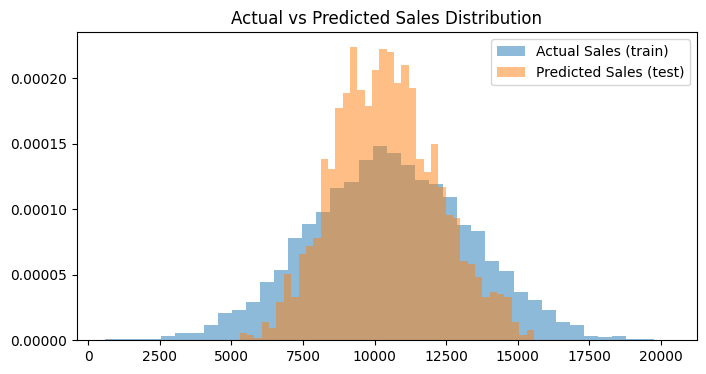

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(train['Sales (Units)'], bins=40, alpha=0.5, label='Actual Sales (train)', density=True)
plt.hist(submission_df['Predicted Sales (Units)'], bins=40, alpha=0.5, label='Predicted Sales (test)', density=True)
plt.legend()
plt.title('Actual vs Predicted Sales Distribution')
plt.show()

A Kolmogorov-Smirnov test comparing actual training Sales to predicted test Sales returned a significant result (KS=0.117, p<0.001), and visual inspection confirms the predicted distribution is narrower than the actual distribution, consistent with Random Forest's tendency to regress predictions toward the mean by averaging across trees. This means the model is likely under-predicting for exceptionally high- or low-performing campaigns, while remaining reliable for typical, average-range campaigns. This is a known limitation of tree-based ensemble models and should be noted as a caveat for business use — the model's predictions are best trusted for typical campaigns and treated cautiously at the extremes.

###  Feature-range coverage check — is test data asking the model to extrapolate?

In [ ]:
for col in ['Followers', 'EngagementRate (%)', 'AdSpend (GBP)', 'ContentQuality']:
  train_min, train_max = train[col].min(), train[col].max()
  out_of_range = ((submission_df[col] < train_min) | (submission_df[col] > train_max)).sum()
  print(f'{col}: {out_of_range} test rows outside training range ({train_min:.1f}, {train_max:.1f})')

Followers: 0 test rows outside training range (17503.4, 180450.4)
EngagementRate (%): 4 test rows outside training range (0.5, 5.0)
AdSpend (GBP): 0 test rows outside training range (1173.8, 8811.1)
ContentQuality: 0 test rows outside training range (1.0, 9.0)


###  Consistency check — do predicted Sales correlate with features the same way actual Sales did?

In [ ]:
test_corr = submission_df[['Followers','EngagementRate (%)','AdSpend (GBP)','ContentQuality','Predicted Sales (Units)']].corr()['Predicted Sales (Units)']
print(test_corr)
print()
print('Compare against original train correlations with actual Sales:')
print(train[['Followers','EngagementRate (%)','AdSpend (GBP)','ContentQuality']].corrwith(train['Sales (Units)']))

Followers                  0.689114
EngagementRate (%)         0.094438
AdSpend (GBP)              0.564898
ContentQuality             0.223992
Predicted Sales (Units)    1.000000
Name: Predicted Sales (Units), dtype: float64

Compare against original train correlations with actual Sales:
Followers             0.494379
EngagementRate (%)    0.076523
AdSpend (GBP)         0.404614
ContentQuality        0.166320
dtype: float64


# Section F: Business Insights & Pipeline Design
### Goal
* Translate model results into actionable insights and design a solution that can be reused.
### Hints
* Identify which features have the strongest influence on predicted sales and explain why this makes sense from a marketing perspective.
* Think about how this model could be used to evaluate future influencer campaigns before money is spent.
* Design a simple and reliable pipeline that can accept new, messy campaign data and produce predictions.
### Success Measurement
* Focus on both predictive accuracy and business usefulness.
* Explain how this solution helps marketing teams make better, data-driven decisions.


### Pipeline Design -  Packaging section A into reusable function

In [ ]:
import pandas as pd
import joblib  # for saving/loading the trained model and stored medians/fences
from typing import Dict, Tuple

def predict_sales(raw_df: pd.DataFrame,
                  model: RandomForestRegressor,
                  train_stats: Dict[str, Dict[str, float | Tuple[float, float]]]) -> pd.DataFrame:
    """
    Accepts raw, potentially messy campaign data and returns Sales predictions.

    train_stats: dict containing fitted values from the ORIGINAL training set
                 (medians, IQR fences) — never recalculated from new data.
    """
    df = raw_df.copy()

    # 1. Clean formatting artifacts (currency symbols, percent signs)
    df['EngagementRate (%)'] = pd.to_numeric(
        df['EngagementRate (%)'].astype(str).str.replace('%', '', regex=False), errors='coerce'
    )
    df['AdSpend (GBP)'] = pd.to_numeric(
        df['AdSpend (GBP)'].astype(str).str.replace('£', '', regex=False), errors='coerce'
    )

    # 2. Fix impossible negative values
    df.loc[df['EngagementRate (%)'] < 0, 'EngagementRate (%)'] = None
    df.loc[df['AdSpend (GBP)'] < 0, 'AdSpend (GBP)'] = None

    # 3. Impute missing values using TRAINING medians (never recompute from new data)
    for col in ['Followers', 'EngagementRate (%)', 'AdSpend (GBP)', 'ContentQuality']:
        df[col] = df[col].fillna(train_stats['medians'][col])

    # 4. Cap outliers using TRAINING IQR fences
    for col in ['Followers', 'AdSpend (GBP)']:
        lower, upper = train_stats['fences'][col]
        df[col] = df[col].clip(lower, upper)

    # 5. Select model features in the correct order
    features = ['Followers', 'EngagementRate (%)', 'AdSpend (GBP)', 'ContentQuality']
    X_new = df[features]

    # 6. Predict
    df['Predicted Sales (Units)'] = model.predict(X_new)

    return df


### Testing the pipeline

In [ ]:
# --- Test---
# Save these once, from your training pipeline:
import pandas as pd
import joblib

# Compute fences directly from train — no dependency on separately-named variables
followers_q1, followers_q3 = train['Followers'].quantile(0.25), train['Followers'].quantile(0.75)
followers_iqr = followers_q3 - followers_q1
followers_lower = followers_q1 - 1.5 * followers_iqr
followers_upper = followers_q3 + 1.5 * followers_iqr

adspend_q1, adspend_q3 = train['AdSpend (GBP)'].quantile(0.25), train['AdSpend (GBP)'].quantile(0.75)
adspend_iqr = adspend_q3 - adspend_q1
adspend_lower = adspend_q1 - 1.5 * adspend_iqr
adspend_upper = adspend_q3 + 1.5 * adspend_iqr

train_stats = {
    'medians': {
        'Followers': train['Followers'].median(),
        'EngagementRate (%)': train['EngagementRate (%)'].median(),
        'AdSpend (GBP)': train['AdSpend (GBP)'].median(),
        'ContentQuality': train['ContentQuality'].median(),
    },
    'fences': {
        'Followers': (followers_lower, followers_upper),
        'AdSpend (GBP)': (adspend_lower, adspend_upper),
    }
}

print(train_stats)

joblib.dump(final_production_model, 'sales_model.pkl')
joblib.dump(train_stats, 'train_stats.pkl')

# Later, for any new campaign data file:
new_campaigns = pd.read_csv('sample_new_campaigns.csv')
model = joblib.load('sales_model.pkl')
stats = joblib.load('train_stats.pkl')
results = predict_sales(new_campaigns, model, stats)
print(results[['ID', 'Predicted Sales (Units)']])

{'medians': {'Followers': 99120.5, 'EngagementRate (%)': 2.80169046143975, 'AdSpend (GBP)': 5005.219029545049, 'ContentQuality': 5.0}, 'fences': {'Followers': (np.float64(17503.375), np.float64(180450.375)), 'AdSpend (GBP)': (np.float64(1173.7708132517905), np.float64(8811.133785537219))}}
     ID  Predicted Sales (Units)
0  9001              9777.179286
1  9002             12963.634677
2  9003              8601.065972
3  9004              6354.028213
4  9005             15844.760371
5  9006              8080.523993
6  9007             14890.099197


# Conclusion on Section F


1.   Followers and AdSpend have the strongest influence on predicted Sales, which aligns with intuitive marketing logic: Followers represents the size of the addressable audience a campaign can reach, while AdSpend represents the investment behind amplifying that reach further (e.g., paid promotion, ad placement). Both are direct levers of exposure — the more people who see a campaign, the more opportunities exist for conversion into Sales. ContentQuality showed a moderate effect, suggesting message quality matters but less than sheer reach. EngagementRate showed the weakest effect, which is a genuinely useful finding for stakeholders who might assume high engagement (likes/comments) automatically drives sales — this dataset suggests reach and budget matter more than audience engagement level.

1.   Before committing budget to a new influencer, the marketing team can input that creator's known attributes (Followers count, historical EngagementRate, ContentQuality assessment, and proposed AdSpend) into the model to generate a predicted Sales figure. This allows campaigns to be ranked and compared before money is spent — e.g., comparing predicted Sales-per-pound-spent across several candidate influencers to prioritize the most efficient options, or simulating 'what if we increased AdSpend by X' for a given creator to estimate expected returns. As new campaigns complete and real Sales data becomes available, the model should be periodically retrained on the growing dataset to keep its predictions current with evolving market conditions.
2.   This solution balances predictive accuracy with practical usability. The final Random Forest model achieves a validation R² of 0.426 with consistent performance across cross-validation folds, indicating it generalizes reasonably well rather than overfitting to training noise — though the KS-test finding (predictions regressing toward the mean) means the model is most reliable for typical campaigns and should be used cautiously when evaluating potential breakout or underperforming outliers. Business-wise, the model translates campaign attributes marketing teams already have access to before launch (Followers, AdSpend, ContentQuality, EngagementRate) into an estimated Sales outcome, enabling data-driven comparison and prioritization of influencer partnerships before committing budget — replacing guesswork with a quantified, evidence-based estimate, while the reusable pipeline ensures this can be applied consistently to new campaign data as it becomes available.


